In [1]:
import os

import numpy as np
import euler_disk as ed
import matplotlib.pyplot as plt
from scipy import signal

# Notebook Data Analysis of Euler Disk
Note: This is the single file version of the data analysis notebook, intended to perform analysis of all of the experimental data in every run.

## Input Data Folder
Under this folder are all the wav files.

In [2]:
input_dir = "../data/wav/recording_04.wav"
output_dir = "../data/output/recording_04/"
os.makedirs(output_dir, exist_ok=True)

## Step 1: Welch's Method
We must find the overall frequency contents of our signal and find the harmonics of the fundamental frequncy to then later do a correct bandpass filtering for further processing.
First we perform an stimation of the power spectral density, computing the overall frequency contents of our signal over the recorded time.

In [3]:
window_size=4096
hop_size=1024

ed.welch(input_path=input_dir, output_dir=output_dir, window_size=window_size, hop_size=hop_size)

/home/roldan/EulerDisk/src/euler_disk/signal_processing.py:148: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wavfile.read(input_path)


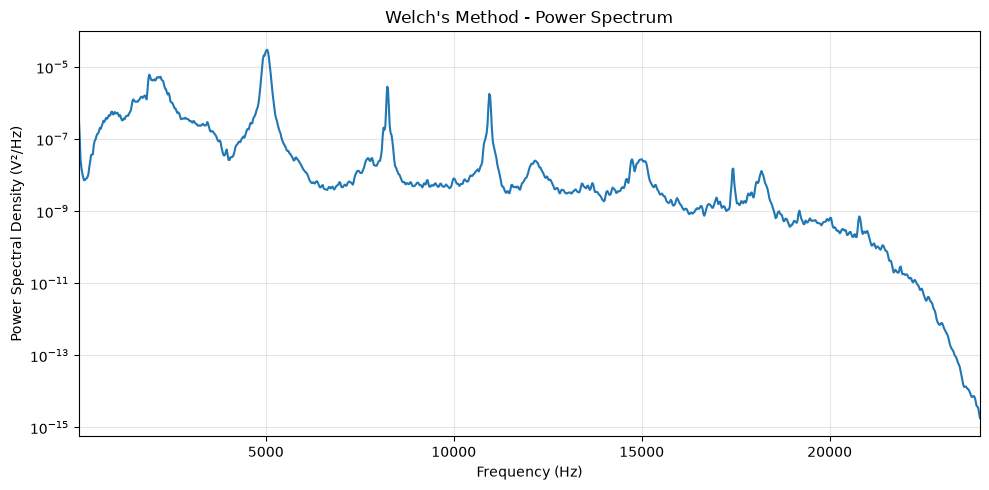

In [4]:
data_welch = np.load(f"{output_dir}/data_welch.npz")
freq, power = data_welch["frequencies"], data_welch["power"]

f_min, f_max = 20, 24000

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freq, power)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (V²/Hz)")
ax.set_title("Welch's Method - Power Spectrum")
ax.set_xlim(f_min, f_max)
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## Step 2: Identify Harmonic's Peaks
We use our own function that uses scipy.find_peaks to find the exact first harmonics and then choose our bandpass for AM processing.

In [5]:
peaks = ed.peaks(
    input_path=f"{output_dir}/data_welch.npz",
    output_dir=f"{output_dir}",
    prominence=6,   # dB
    distance=2,     # bins (~47 Hz at Δf≈23.4 Hz)
)

n = len(peaks["frequencies"])
print(f"\nFound {n} peaks:\n")
print(f"{'Frequency (Hz)':<18} {'Power (V²/Hz)':<18} {'Prominence (dB)':<18}")
print("-" * 54)

freqs = peaks["frequencies"]
powers = peaks["powers"]
proms = peaks.get("prominences", [None] * n)

for f, p, pr in zip(freqs, powers, proms):
    prom_str = f"{pr:<18.2f}" if pr is not None else f"{'—':<18}"
    print(f"{f:<18.2f} {p:<18.3e} {prom_str}")


Found 8 peaks:

Frequency (Hz)     Power (V²/Hz)      Prominence (dB)   
------------------------------------------------------
1898.44            6.176e-06          23.74             
5039.06            3.030e-05          36.22             
8226.56            2.862e-06          28.64             
10945.31           1.805e-06          26.18             
12164.06           2.541e-08          9.04              
15000.00           2.769e-08          11.68             
17437.50           1.529e-08          13.10             
18187.50           1.303e-08          9.46              


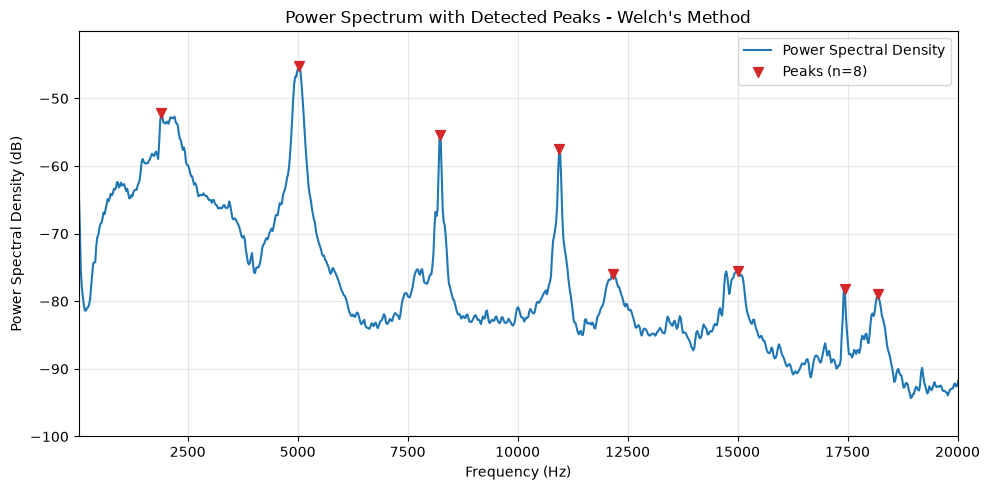

In [6]:
peak_data = np.load(f"{output_dir}/peak_data.npz")

welch_db = 10 * np.log10(data_welch["power"] + 1e-20)
peak_db = 10 * np.log10(peak_data["powers"] + 1e-20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_yscale("linear")
ax.plot(data_welch["frequencies"], welch_db, label="Power Spectral Density", color="tab:blue")
ax.scatter(peak_data["frequencies"], peak_db, color="tab:red", s=50, marker="v", label=f"Peaks (n={len(peak_data['frequencies'])})", zorder=5)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (dB)")
ax.set_title("Power Spectrum with Detected Peaks - Welch's Method")
ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(f_min, 20000)
ax.set_ylim(-100)
ax.legend()
fig.tight_layout()
plt.show()

# Step 3: Bandpass Filtering
We then apply a bandpass filter to isolate the most prominent peak from last step.

In [ ]:
bandpass_center_hz = 1898.44

ed.bandpass(
    input_path=input_dir,
    output_dir=output_dir,
    center_freq_hz=bandpass_center_hz,
    bandwidth_hz=250,
    filter_order=4,
)

{'signal': array([-4.74461607e-04,  4.25164289e-05,  5.54226562e-04, ...,
        -2.11465156e-07, -2.61034288e-07, -2.68660005e-07],
       shape=(2512213,)),
 'rate': 96000,
 'center_freq_hz': 5039.0625}

## Step 4: Envelope 
Now we must use amplitude demodulation to reduce the AM artifacts in our signal. We perform a Hilbert transform to obtain the *analytic signal*, a complex value whose magnitude is the amplitude, obtaining the envelope.

In [8]:
ed.envelope(
    filtered_signal_path=f"{output_dir}/filtered_signal.npz",
    output_dir=output_dir,
    smooth_window=1920,
)

{'time': array([0.00000000e+00, 1.04166667e-05, 2.08333333e-05, ...,
        2.61688542e+01, 2.61688646e+01, 2.61688750e+01], shape=(2512213,)),
 'envelope': array([0.00127624, 0.00127822, 0.00128019, ..., 0.00156788, 0.00156564,
        0.00156339], shape=(2512213,)),
 'center_freq_hz': 5039.0625}

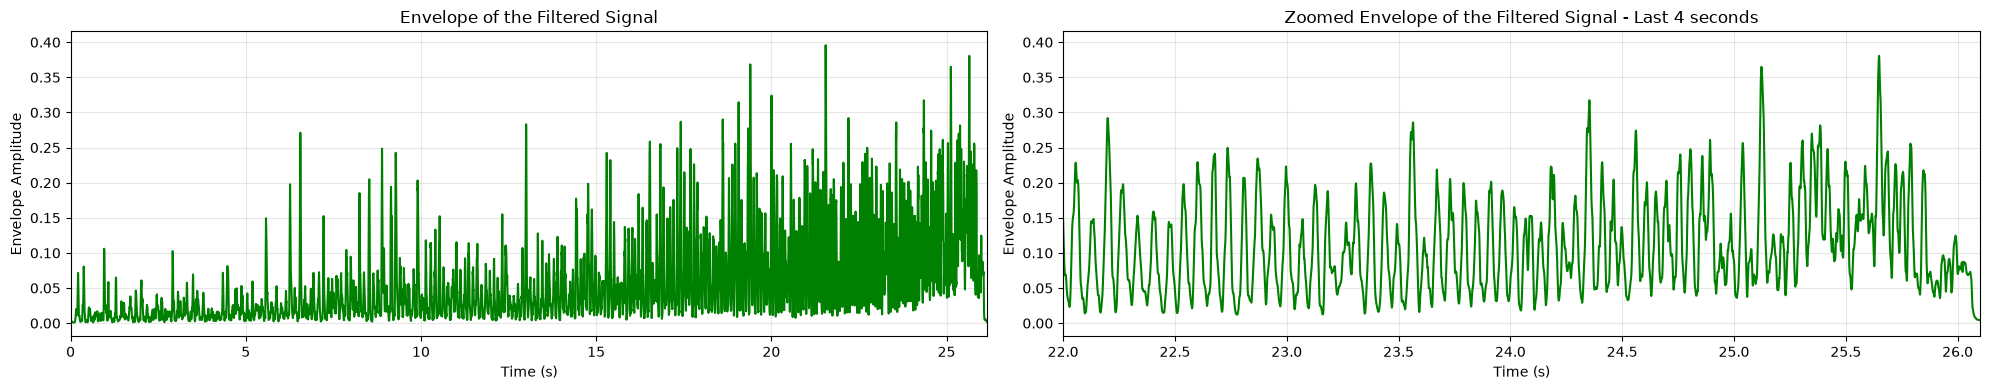

In [9]:
envelope_data = np.load(f"{output_dir}/envelope.npz")

time, envelope = envelope_data["time"], envelope_data["envelope"]

fig, ax = plt.subplots(1,2,figsize=(20, 4))
ax[0].plot(time, envelope, color="g")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Envelope Amplitude")
ax[0].set_title("Envelope of the Filtered Signal")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].set_xlim(time[0], time[-1])

ax[1].plot(time, envelope, color="g")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Envelope Amplitude")
ax[1].set_title("Zoomed Envelope of the Filtered Signal - Last 4 seconds")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].set_xlim(22, 26.1)

fig.tight_layout()
plt.show()

## Step 5: Spectogram
Now that we applied our AM correction filters and narrow our search to a harmonic band, we plot the spectogram of the processed signal near the singularity.

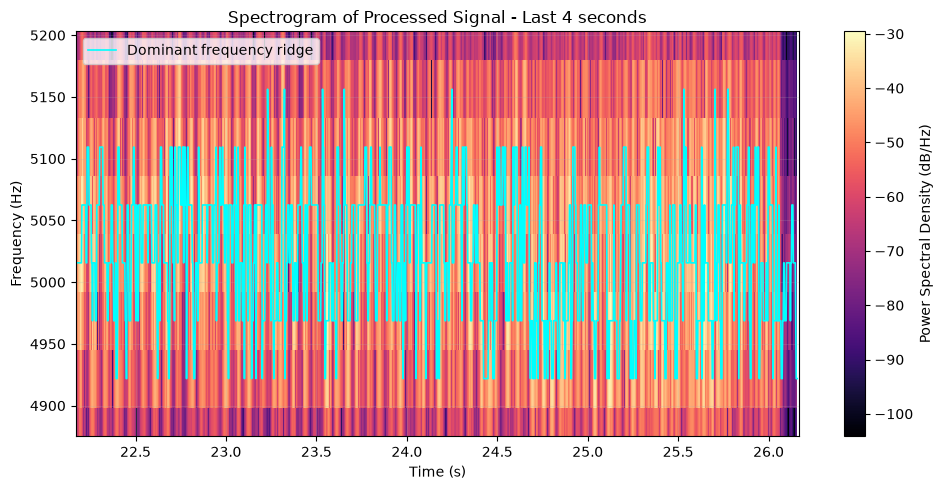

In [10]:
filtered_data = np.load(f"{output_dir}/filtered_signal.npz")
processed_signal = filtered_data["signal"]
rate = float(filtered_data["rate"])
center_freq = float(filtered_data["center_freq_hz"])

singularity_time = len(processed_signal) / rate
spectrogram_window_s = 4.0
spectrogram_start = max(0.0, singularity_time - spectrogram_window_s)

start_sample = int(spectrogram_start * rate)
processed_tail = processed_signal[start_sample:]

spectrogram_nperseg = 2048
spectrogram_noverlap = 1792

frequencies, spectrogram_times, spectrogram_power = signal.spectrogram(
    processed_tail,
    fs=rate,
    window="hann",
    nperseg=spectrogram_nperseg,
    noverlap=spectrogram_noverlap,
    detrend="constant",
    scaling="density",
    mode="psd",
)
spectrogram_times = spectrogram_times + spectrogram_start
spectrogram_db = 10 * np.log10(spectrogram_power + 1e-20)

spectrogram_bandwidth_hz = 350
freq_mask = (
    (frequencies >= center_freq - spectrogram_bandwidth_hz / 2)
    & (frequencies <= center_freq + spectrogram_bandwidth_hz / 2)
)

band_frequencies = frequencies[freq_mask]
band_spectrogram_db = spectrogram_db[freq_mask, :]
ridge_frequency = band_frequencies[np.argmax(band_spectrogram_db, axis=0)]

fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    spectrogram_times,
    band_frequencies,
    band_spectrogram_db,
    shading="auto",
    cmap="magma",
)
ax.plot(
    spectrogram_times,
    ridge_frequency,
    color="cyan",
    linewidth=1.2,
    label="Dominant frequency ridge",
)
ax.axvline(singularity_time, color="white", linestyle="--", linewidth=1, alpha=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram of Processed Signal - Last 4 seconds")
ax.set_xlim(spectrogram_start, singularity_time)
ax.set_ylim(band_frequencies[0], band_frequencies[-1])
ax.grid(True, which="both", alpha=0.2)
ax.legend(loc="upper left")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Power Spectral Density (dB/Hz)")

fig.tight_layout()
plt.show()